In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [10]:
ckd = pd.read_csv("../data/ckd.csv")

ckd.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [11]:
print(ckd.shape)
ckd.info()

(400, 25)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe 

In [12]:
ckd = ckd.replace("?", np.nan)
numeric_cols = [
    "age", "bp", "sg", "al", "su", "bgr", "bu", "sc",
    "sod", "pot", "hemo", "pcv", "wbcc", "rbcc"
]

for col in numeric_cols:
    ckd[col] = pd.to_numeric(ckd[col], errors="coerce")

for col in numeric_cols:
    ckd[col] = ckd[col].fillna(ckd[col].median())

categorical_cols = [col for col in ckd.columns if col not in numeric_cols]

for col in categorical_cols:
    ckd[col] = ckd[col].fillna(ckd[col].mode()[0])

In [13]:
ckd.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    float64
 3   al      400 non-null    float64
 4   su      400 non-null    float64
 5   rbc     400 non-null    str    
 6   pc      400 non-null    str    
 7   pcc     400 non-null    str    
 8   ba      400 non-null    str    
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    str    
 19  dm      400 non-null    str    
 20  cad     400 non-null    str    
 21  appet   400 non-null    str    
 22  pe      400 n

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_cols = ckd.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    ckd[col] = label_encoder.fit_transform(ckd[col])

ckd.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [15]:
print(ckd.shape)
ckd.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = ckd.drop(columns=["class"])
y = ckd["class"]

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Feature Matrix Shape :", X.shape)
print("Training Set Shape   :", X_train.shape)
print("Testing Set Shape    :", X_test.shape)
print("Training Labels      :", y_train.shape)
print("Testing Labels       :", y_test.shape)

Feature Matrix Shape : (400, 24)
Training Set Shape   : (320, 24)
Testing Set Shape    : (80, 24)
Training Labels      : (320,)
Testing Labels       : (80,)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the Adaptive MLP model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

print("\nModel training completed successfully.")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6094 - loss: 0.6344 - val_accuracy: 0.6562 - val_loss: 0.5979
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6406 - loss: 0.5802 - val_accuracy: 0.8594 - val_loss: 0.5387
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6641 - loss: 0.5403 - val_accuracy: 0.9062 - val_loss: 0.4791
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7344 - loss: 0.4912 - val_accuracy: 0.9219 - val_loss: 0.4302
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8164 - loss: 0.4278 - val_accuracy: 0.9062 - val_loss: 0.3901
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8672 - loss: 0.3749 - val_accuracy: 0.9062 - val_loss: 0.3517
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9062 - loss: 0.3442 - val_accuracy: 0.9062 - val_loss: 0.3098
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9141 - loss: 0.2989 - val_accuracy: 0.9219 - val_loss: 0.2602
Epo

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("Generalization Test Results")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Generalization Test Results
Accuracy : 0.9875
Precision: 0.9677
Recall   : 1.0000
F1 Score : 0.9836
ROC AUC  : 0.9993

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


Confusion Matrix
[[49  1]
 [ 0 30]]


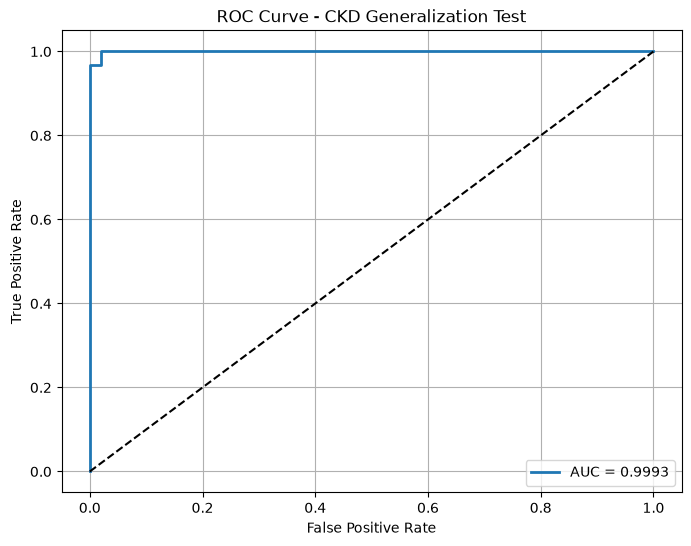

In [20]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CKD Generalization Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

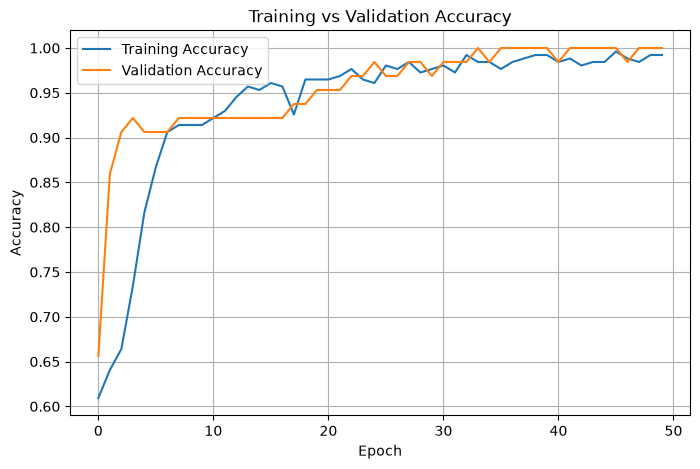

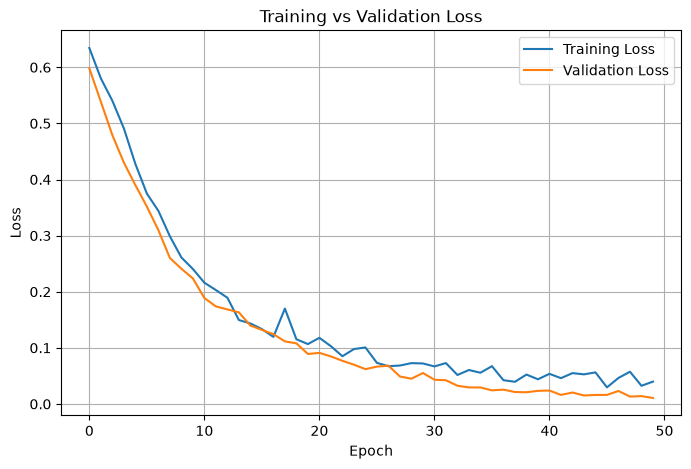

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
results = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

results.to_csv("../results/generalization_results.csv", index=False)

print(results)

print("Results saved successfully.")

   Accuracy  Precision  Recall  F1_Score   ROC_AUC
0    0.9875   0.967742     1.0  0.983607  0.999333
Results saved successfully.


In [23]:
print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
class
0    200
1    120
Name: count, dtype: int64

Testing Class Distribution
class
0    50
1    30
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

mlp_cv = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

cv_scores = cross_val_score(
    mlp_cv,
    X_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[1.     1.     0.975  0.975  0.9875]

Mean Accuracy: 0.9875
Standard Deviation: 0.011180339887498959


In [25]:
cv_results = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Accuracy": cv_scores
})

cv_results.to_csv(
    "../results/cross_validation_results.csv",
    index=False
)

cv_results

,Fold,Accuracy
0,1,1.0000
1,2,1.0000
2,3,0.9750
3,4,0.9750
4,5,0.9875


In [26]:
comparison = pd.DataFrame({
    "Dataset":["Pima Diabetes","CKD"],
    "Accuracy":[0.7467, accuracy],
    "Precision":[0.6379, precision],
    "Recall":[0.6727, recall],
    "F1_Score":[0.6548, f1],
    "ROC_AUC":[0.8128, roc_auc]
})

comparison

,Dataset,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Pima Diabetes,0.7467,0.637900,0.6727,0.654800,0.812800
1,CKD,0.9875,0.967742,1.0000,0.983607,0.999333


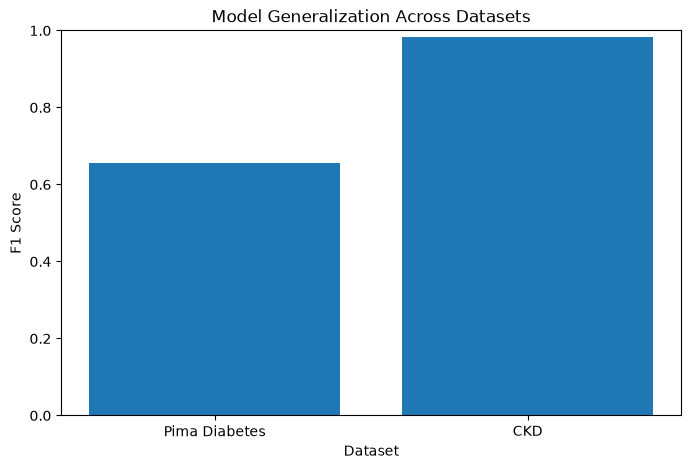

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Dataset"],
    comparison["F1_Score"]
)

plt.xlabel("Dataset")
plt.ylabel("F1 Score")
plt.title("Model Generalization Across Datasets")

plt.ylim(0,1)

plt.show()